In [12]:
import json
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportion_confint

%matplotlib inline

In [13]:
repository_path = pathlib.Path.cwd().parents[2]
simulations_path = repository_path / "data" / "simulations"
hypothesis_results_path = repository_path / "data" / "hypothesis_results"

In [14]:
simulation_games_data = pd.read_csv(simulations_path / "games.csv")

# Hypothesis 1 - Player-count balance

**Question.** Does the number of players change the team's win probability?

- **$H_0$:** $P(\text{win} \mid 6\ \text{players}) = P(\text{win} \mid 7\ \text{players}) = P(\text{win} \mid 8\ \text{players})$
- **$H_1$:** at least one of the three win probabilities differs from the others

**Test.** Chi-square goodness-of-fit on the observed win counts across the three player-count groups, against equal expected counts (the simpler one-way form is valid here because the three groups have equal sample size of 4,000 games each). Per-group 95% Wilson confidence intervals on the win rate as supplementary effect sizes. Significance level $\alpha = 0.05$. The decision is reported here against the uncorrected threshold; the Holm-Bonferroni correction across all seven hypotheses is applied in the summary table in the main notebook.

**Sanity check.** The sampling plan specifies 4,000 games per player count (12,000 total). The one-way chi-square form used below assumes the three groups have equal sample size, so confirming the per-count totals match the plan is a precondition for the test, not just a courtesy print-out.

In [15]:
games_per_count = simulation_games_data.groupby("player_count").size()
games_per_count

player_count
6    4000
7    4000
8    4000
dtype: int64

**Contingency table** of outcome by player count, followed by the per-group win rate.

In [16]:
game_outcomes_per_player_count = simulation_games_data.pivot_table(
    index = "player_count",
    columns = "outcome",
    aggfunc = "size",
    fill_value = 0,
)
game_outcomes_per_player_count

outcome,loss,win
player_count,,
6,2317,1683
7,2084,1916
8,1912,2088


In [17]:
win_rate_per_player_count = game_outcomes_per_player_count["win"] / games_per_count
win_rate_per_player_count

player_count
6    0.42075
7    0.47900
8    0.52200
dtype: float64

**Observation.** Win share already shifts noticeably with player count: 42% at 6, 48% at 7, 52% at 8 - a climb of roughly six percentage points per added player. That trend is the candidate effect for the test. Whether it is large enough to reject the equal-rate null, given the 4,000-game per-group sample, is what the chi-square test below decides.

**Plot** the per-group win rates for orientation before running the test.

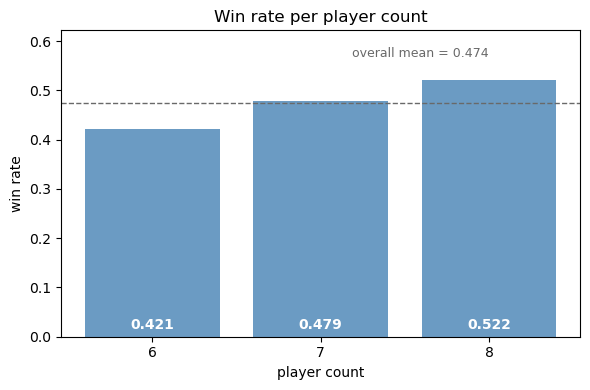

In [18]:
overall_win_rate = game_outcomes_per_player_count["win"].sum() / games_per_count.sum()

plt.figure(figsize = (6, 4))

plt.bar(win_rate_per_player_count.index, win_rate_per_player_count.values,
        color = "steelblue", alpha = 0.8)

plt.axhline(overall_win_rate, color = "dimgray", linestyle = "--", linewidth = 1)
plt.text(win_rate_per_player_count.index.max(),
         win_rate_per_player_count.max() + 0.04,
         f"overall mean = {overall_win_rate:.3f}",
         va = "bottom", ha = "right", fontsize = 9, color = "dimgray")

plt.xticks(win_rate_per_player_count.index)
plt.xlabel("Player count")
plt.ylabel("Win rate")
plt.ylim(0, win_rate_per_player_count.max() + 0.10)
plt.title("Win rate by player count")

for player_count, win_rate in win_rate_per_player_count.items():
    plt.text(player_count, 0.01, f"{win_rate:.3f}",
             ha = "center", va = "bottom", color = "white", fontweight = "bold", fontsize = 10)
plt.tight_layout()

plt.show()

**Chi-square test** against equal expected win counts across the three player-count groups. This is the formal counterpart to the visual trend above: the test asks whether the deviations from the equal-rate null are large enough to reject sample noise as the explanation, given the per-group sample size.

In [19]:
chisquare_result = chisquare(
    f_obs = game_outcomes_per_player_count["win"],
    f_exp = [game_outcomes_per_player_count["win"].mean()] * len(game_outcomes_per_player_count),
)

print(f"chi-square statistic: {chisquare_result.statistic:.4f}")
print(f"p-value:              {chisquare_result.pvalue:.2e}")

chi-square statistic: 43.5903
p-value:              3.42e-10


**Observation.** $p = 3.4 \times 10^{-10}$ sits many orders of magnitude below $\alpha = 0.05$, so the data are essentially incompatible with the equal-rate null - the chi-square rejects $H_0$ globally. What it does *not* say is which pair (or pairs) of player counts drive the rejection; the global test only flags that at least one of the three rates differs from the others. That localisation is what the per-group Wilson confidence intervals below address.

**95% Wilson confidence intervals** per player count. Non-overlapping intervals imply pairwise differences significant at the 5% level without needing a separate pairwise test.

In [20]:
for player_count in win_rate_per_player_count.index:
    wins = game_outcomes_per_player_count.loc[player_count, "win"]
    total_games = games_per_count.loc[player_count]
    ci_lower, ci_upper = proportion_confint(wins, total_games, method = "wilson")
    win_rate = win_rate_per_player_count.loc[player_count]

    print(f"{player_count} players: win rate = {win_rate:.4f}, 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

6 players: win rate = 0.4208, 95% CI = [0.4055, 0.4361]
7 players: win rate = 0.4790, 95% CI = [0.4635, 0.4945]
8 players: win rate = 0.5220, 95% CI = [0.5065, 0.5375]


**Observation.** All three intervals are disjoint - 6 players ([0.41, 0.44]) sits entirely below 7 players ([0.46, 0.49]), which sits entirely below 8 players ([0.51, 0.54]). Two non-overlapping 95% CIs imply a pairwise difference significant at the 5% level, so every pair of player counts differs significantly. The effect is therefore not just global but *monotone* across all three counts: not driven by a single outlier group.

## Decision

The chi-square test gives $\chi^2 = 43.59$ with $p = 3.4 \times 10^{-10}$, well below $\alpha = 0.05$, so we **reject $H_0$** in favour of $H_1$: win probability is not the same across the three player counts. The three Wilson 95% confidence intervals are disjoint (`[0.406, 0.436]`, `[0.464, 0.494]`, `[0.506, 0.538]`), which confirms each pairwise difference at the 5% level independently of the global test.

The direction is consistent: win rate rises monotonically with player count, from 42.1% at 6 players to 47.9% at 7 and 52.2% at 8. That runs counter to the naive design expectation that larger groups would struggle more with coordination - in this simulation, more players means more available hands to absorb the per-participant resource costs of complications and volcano cards, which more than offsets the additional boat-part requirement. **Volcano Rush is therefore not balanced across player counts under the current rules**, and the 6-player configuration in particular sits below the 50-65% design-target band. This should be flagged as a balance concern in the discussion section of the main notebook.

In [21]:
hypothesis_result = {
    "hypothesis": "H1",
    "description": "Player-count balance",
    "test": "chi-square",
    "p_value": float(chisquare_result.pvalue),
}

hypothesis_results_path.mkdir(parents = True, exist_ok = True)
with open(hypothesis_results_path / "h1.json", "w") as output_file:
    json.dump(hypothesis_result, output_file, indent = 2)

print(json.dumps(hypothesis_result, indent = 2))

{
  "hypothesis": "H1",
  "description": "Player-count balance",
  "test": "chi-square",
  "p_value": 3.4236392854209937e-10
}
